In [ ]:
!pip install -q google-genai
print("✅ Instalación completa")

✅ Instalación completa


In [ ]:
from google.colab import userdata
from google import genai
import os

# Conexión con tu API Key
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
client = genai.Client(api_key=os.environ['GOOGLE_API_KEY'])

print("✅ Cliente Gemini conectado y listo, Gerardo!")

✅ Cliente Gemini conectado y listo, Gerardo!


In [ ]:
from google.colab import files

# Activamos el botón para seleccionar archivos
print("📂 Selecciona tus 4 PDFs de Carrarurquia, Gerardo:")
uploader = files.upload()

# Cargamos cada archivo al cerebro de Gemini
docs_para_gemini = []
for nombre in uploader.keys():
    print(f"📄 Enviando a Gemini: {nombre}...")
    archivo_ia = client.files.upload(file=nombre)
    docs_para_gemini.append(archivo_ia)
    print(f"   ✅ Listo: {archivo_ia.name}")

print(f"\n🎉 {len(docs_para_gemini)} archivos cargados y listos para consultar!")

📂 Selecciona tus 4 PDFs de Carrarurquia, Gerardo:


Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf
Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf
📄 Enviando a Gemini: Carrarurquia_Reporte_Q1_2025.pdf...
   ✅ Listo: files/90a62hoq4fl2
📄 Enviando a Gemini: Carrarurquia_Reporte_Q2_2025.pdf...
   ✅ Listo: files/kgw3yi1a69ip
📄 Enviando a Gemini: Carrarurquia_Reporte_Q3_2025.pdf...
   ✅ Listo: files/t75s9h02jdva
📄 Enviando a Gemini: Carrarurquia_Reporte_Q4_2025.pdf...
   ✅ Listo: files/7fjd9cmlz9wr

🎉 4 archivos cargados y listos para consultar!


In [ ]:
!pip install -q langchain-community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
documentos = []

for archivo2 in os.listdir("PDFs"):
  ruta = os.path.join("PDFs", archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [ ]:
from typing import TypedDict

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [ ]:
from langgraph.graph import StateGraph, START, END

grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

In [ ]:
import os

os.makedirs("PDFs", exist_ok=True)

# Movemos los archivos que subiste al directorio PDFs
for nombre in uploader.keys():
    os.rename(nombre, f"PDFs/{nombre}")

print("✅ Archivos movidos a la carpeta PDFs")
print(os.listdir("PDFs"))

FileNotFoundError: [Errno 2] No such file or directory: 'Carrarurquia_Reporte_Q1_2025.pdf' -> 'PDFs/Carrarurquia_Reporte_Q1_2025.pdf'

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documentos = []

for archivo2 in os.listdir("PDFs"):
    ruta = os.path.join("PDFs", archivo2)
    loader = PyPDFLoader(ruta)
    paginas = loader.load()
    documentos.extend(paginas)

print(f"✅ {len(documentos)} páginas cargadas correctamente")

✅ 60 páginas cargadas correctamente


In [ ]:
import os

os.makedirs("PDFs", exist_ok=True)

# Movemos los archivos que subiste al directorio PDFs
for nombre in uploader.keys():
    os.rename(nombre, f"PDFs/{nombre}")

print("✅ Archivos movidos a la carpeta PDFs")
print(os.listdir("PDFs"))

FileNotFoundError: [Errno 2] No such file or directory: 'Carrarurquia_Reporte_Q1_2025.pdf' -> 'PDFs/Carrarurquia_Reporte_Q1_2025.pdf'

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documentos = []

for archivo2 in os.listdir("PDFs"):
    ruta = os.path.join("PDFs", archivo2)
    loader = PyPDFLoader(ruta)
    paginas = loader.load()
    documentos.extend(paginas)

print(f"✅ {len(documentos)} páginas cargadas correctamente")

✅ 60 páginas cargadas correctamente


In [ ]:
documentos [0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [ ]:
len(documentos)

60

In [ ]:
!pip install -q langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

In [ ]:
fragmentos[67]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:30:27+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:30:27+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q1_2025.pdf', 'total_pages': 15, 'page': 8, 'page_label': '9'}, page_content='5. Operaciones y calidad\nEntrega del viaje\nEn Q1 se operaron 68 salidas (grupales y semi-privadas), con un cumplimiento de\nitinerario del 93%. Las incidencias se concentraron en traslados interurbanos en días de\nlluvia y en reprogramaciones por disponibilidad de actividades.\nCadena de suministro y proveedores\nProveedor\nTipo\nRegión\nParticipación de coste\nEvaluación (1-5)\nBosporus DMC\nOperador local')

In [ ]:
!pip install -q langchain-google-genai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.9 MB/s eta 0:00:00


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [ ]:
len(fragmentos)

172

In [ ]:
display(fragmentos[0])
print(f"Total de fragmentos: {len(fragmentos)}")

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'PDFs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una')

Total de fragmentos: 172


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/text-embedding-004",
    google_api_key=os.environ['GOOGLE_API_KEY']
)

print(f"✅ Embeddings listos")
print(f"📦 Total de fragmentos a vectorizar: {len(fragmentos)}")

✅ Embeddings listos
📦 Total de fragmentos a vectorizar: 172


In [ ]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

## 1. Inicialización de Embeddings

Los embeddings se crean utilizando el modelo `gemini-embedding-001` de Google Generative AI. Este modelo convierte los fragmentos de texto en vectores numéricos, lo que permite medir la similitud semántica entre ellos.

```python
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=os.environ['GOOGLE_API_KEY']
)

print(f"✅ Embeddings listos con gemini-embedding-001")
print(f"📦 Total de fragmentos a vectorizar: {len(fragmentos)}")
```

## 2. Creación y Unión de Bases Vectoriales FAISS

Para manejar eficientemente los fragmentos, se crearon dos bases de datos vectoriales FAISS (Facebook AI Similarity Search) a partir de los `fragmentos` generados previamente. Posteriormente, estas dos bases vectoriales se unieron en una sola para formar un índice completo y optimizado.

### Creación de `vectorstore1` (fragmentos 0 al 88)
```python
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)
print("✅ Vectorstore 1 creado con fragmentos 0 al 88")
```

### Creación de `vectorstore2` (fragmentos 89 al final)
```python
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[89:],
    embedding=embeddings
)
print("✅ Vectorstore 2 creado con fragmentos 89 al 172")
```

### Unión de las Bases Vectoriales
```python
vectorstore1.merge_from(vectorstore2)

print("✅ Vectorstores unidos correctamente")
print(f"📦 Total de vectores en el índice final: {vectorstore1.index.ntotal}")
```

### Guardado de la Base Vectorial

Finalmente, la base vectorial unida se guarda localmente en el disco para su uso posterior. Se almacenan dos archivos: `index.pkl` (que contiene la estructura de FAISS) y `index.faiss` (que contiene los propios vectores).

```python
vectorstore1.save_local("mi_base_vectorial")

print("✅ Base vectorial guardada en disco")
print("📁 Archivos guardados:", os.listdir("mi_base_vectorial"))
```

In [ ]:
for modelo in client.models.list():
    if "embed" in modelo.name.lower():
        print(modelo.name)

models/gemini-embedding-001
models/gemini-embedding-2-preview


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=os.environ['GOOGLE_API_KEY']
)

print(f"✅ Embeddings listos con gemini-embedding-001")
print(f"📦 Total de fragmentos a vectorizar: {len(fragmentos)}")

✅ Embeddings listos con gemini-embedding-001
📦 Total de fragmentos a vectorizar: 172


In [ ]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

print("✅ Vectorstore 1 creado con fragmentos 0 al 88")

✅ Vectorstore 1 creado con fragmentos 0 al 88


In [ ]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[89:],
    embedding=embeddings
)

print("✅ Vectorstore 2 creado con fragmentos 89 al 172")

✅ Vectorstore 2 creado con fragmentos 89 al 172


In [ ]:
vectorstore1.merge_from(vectorstore2)

print("✅ Vectorstores unidos correctamente")
print(f"📦 Total de vectores en el índice final: {vectorstore1.index.ntotal}")

✅ Vectorstores unidos correctamente
📦 Total de vectores en el índice final: 172


In [ ]:
vectorstore1.save_local("mi_base_vectorial")

print("✅ Base vectorial guardada en disco")
print("📁 Archivos guardados:", os.listdir("mi_base_vectorial"))

✅ Base vectorial guardada en disco
📁 Archivos guardados: ['index.pkl', 'index.faiss']


In [ ]:
consulta = "Cuál es el paquete de viajes más económico de Carrarurquía?"

resultados = vectorstore1.similarity_search(
    consulta,
    k=7
)

for i, doc in enumerate(resultados):
    print(f"\n--- Fragmento {i+1} ---")
    print(doc.page_content)


--- Fragmento 1 ---
Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación

--- Fragmento 2 ---
Carrarurquía
Reporte trimestral Q4 2025 (ficticio)
Periodo: 01/10/2025 - 31/12/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación

--- Fragmento 3 ---
Carrarurquía
Reporte trimestral Q2 2025 (ficticio)
Periodo: 01/04/2025 - 30/06/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación

--- Fragmento 4 ---
Carrarurquía
 Reporte trimestral Q1 2025 · Via

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2
)

retriever = vectorstore1.as_retriever(
    search_kwargs={"k": 4}
)

In [ ]:
def preguntar_rag(pregunta):
    """Busca contexto relevante en los documentos y genera una respuesta."""
    # Paso 1: Buscar los chunks más relevantes
    docs = retriever.invoke(pregunta)
    contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)

    # Paso 2: Construir el prompt con el contexto encontrado
    prompt = f"""Eres un asistente experto que responde preguntas basándose ÚNICAMENTE
    en el contexto proporcionado. Si la información no está en el contexto,
    di que no tienes suficiente información.

    Contexto: {contexto}

    Pregunta: {pregunta}

    Respuesta:"""

    # Paso 3: Enviar al modelo y devolver la respuesta
    respuesta = llm.invoke(prompt)
    return respuesta.content

In [ ]:
preguntar_rag("Dónde se mantuvo concentrado el mix de productos?")

'El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

In [ ]:
preguntar_rag("Cuántos mundiales de fútbol tiene Brasil?")

'No tengo suficiente información en el contexto proporcionado para responder cuántos mundiales de fútbol tiene Brasil.'

In [ ]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 17.0 MB/s eta 0:00:00


In [ ]:
!pip install -q tavily-python
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [ ]:
from langchain_community.tools.tavily_search import TavilySearchResults

buscador = TavilySearchResults()

resp = buscador.run("¿Cuántos atletas turcos fueron a las olimpiadas de invierno 2026?")
resp

/tmp/ipykernel_3655/9064509.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  buscador = TavilySearchResults()


[{'title': 'Nine Turkish athletes qualify for Milano Cortina Winter Olympics 2026',
  'url': 'https://www.turkiyetoday.com/sports/nine-turkish-athletes-qualify-for-milano-cortina-winter-olympics-2026-3213255',
  'content': 'Competition will begin on Feb. 4 with mixed doubles curling at the historic Cortina Olympic Stadium\n The opening ceremony will take place on Feb. 6 at San Siro Stadium in Milano\n The Games will close on Feb. 22 after the men’s ice hockey final and women’s curling final\n\nTürkiye has sent athletes to the Winter Olympics since 1936. The country has not won a medal at the Winter Games.\n\nTürkiye competed with 7 athletes at the Beijing 2022 Winter Olympics but the delegation has now grown to nine athletes in Italy.\n\nTurkish athletes qualified for Milano Cortina 2026\n\nShort track speed skating\n\n Furkan Akar\n Denis Ors\n\nCross-country skiing\n\n Irem Dursun\n Abdullah Yilmaz\n\nAlpine skiing\n\n Ada Hasirci\n Thomas Kaan Onol Lang\n\nSki jumping\n\n Fatih Arda

In [ ]:
from tavily import TavilyClient

buscador_tavily = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])

resp = buscador_tavily.search("Cuántos atletas turcos fueron a las olimpiadas de invierno 2026?")

print(resp['results'][0]['content'])

# Nine Turkish athletes qualify for Milano Cortina Winter Olympics 2026. Turkish winter sports athletes prepare for the Milano Cortina 2026 Winter Olympics as Türkiye expands its presence at the Winter Games, Italy, Jan. 20. Turkish winter sports athletes prepare for the Milano Cortina 2026 Winter Olympics as Türkiye expands its presence at the Winter Games, Italy, Jan. 20. Newsletters Set as preferred source  Share. Türkiye prepares to send nine athletes to the Milano Cortina 2026 Winter Olympics as the country expands its presence at the Winter Games. Athletes will compete across ice, snow, and para-alpine disciplines as Türkiye continues its pursuit of a first Winter Olympic medal. The 25th Winter Olympic Games will take place in Milano and Cortina d’Ampezzo from Feb. 6 to Feb. 22, 2026. Türkiye has sent athletes to the Winter Olympics since 1936. Türkiye qualified two athletes in this discipline for the first time in Winter Olympics history.


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [ ]:
def nodo_web(state: AgentState):

  contexto = buscador_tavily.search(state["pregunta"])
  contexto = contexto['results'][0]['content']

  return {"contexto": contexto}

In [ ]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [ ]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [ ]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

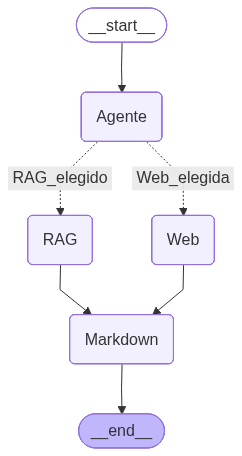

In [ ]:
from IPython.display import Image, display

imagen = agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [ ]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [ ]:
ejecutar_agente("Dónde se mantuvo concentrado el mix de productos?")

El agente decidió la fuente RAG.
Fuente utilizada: RAG
Contexto utilizado: El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).
Respuesta final: # Concentración del Mix de Productos

## Dónde se mantuvo concentrado el mix de productos?

El mix de productos se mantuvo concentrado en **circuitos combinados**.

Específicamente, estos circuitos incluían:
*   **Estambul**
*   **Capadocia**


'# Concentración del Mix de Productos\n\n## Dónde se mantuvo concentrado el mix de productos?\n\nEl mix de productos se mantuvo concentrado en **circuitos combinados**.\n\nEspecíficamente, estos circuitos incluían:\n*   **Estambul**\n*   **Capadocia**'

In [ ]:
ejecutar_agente("Cuántos mundiales de fútbol tiene Brasil?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: Las 5 Mundiales de Brasil (1958-2002). ▷ ¿Cuántos Mundiales de fútbol ha ganado Brasil?
Respuesta final: # Mundiales de Fútbol Ganados por Brasil

Brasil es la selección nacional de fútbol más laureada en la historia de la Copa Mundial de la FIFA, destacándose por su talento y dominio en el deporte rey.

## Total de Títulos Mundiales

La selección brasileña ha ganado un total de **5 (cinco)** Copas Mundiales de la FIFA. Este impresionante récord la convierte en el país con más títulos en la competición.

## Años de las Victorias

Las cinco victorias de Brasil en la Copa Mundial se distribuyen a lo largo de varias décadas, marcando épocas doradas para el fútbol brasileño. Los años en que Brasil levantó el codiciado trofeo son:

*   **1958**: En Suecia, marcando el inicio de la era de Pelé.
*   **1962**: En Chile, defendiendo exitosamente su título.
*   **1970**: En México, con una de las selecciones consideradas 

'# Mundiales de Fútbol Ganados por Brasil\n\nBrasil es la selección nacional de fútbol más laureada en la historia de la Copa Mundial de la FIFA, destacándose por su talento y dominio en el deporte rey.\n\n## Total de Títulos Mundiales\n\nLa selección brasileña ha ganado un total de **5 (cinco)** Copas Mundiales de la FIFA. Este impresionante récord la convierte en el país con más títulos en la competición.\n\n## Años de las Victorias\n\nLas cinco victorias de Brasil en la Copa Mundial se distribuyen a lo largo de varias décadas, marcando épocas doradas para el fútbol brasileño. Los años en que Brasil levantó el codiciado trofeo son:\n\n*   **1958**: En Suecia, marcando el inicio de la era de Pelé.\n*   **1962**: En Chile, defendiendo exitosamente su título.\n*   **1970**: En México, con una de las selecciones consideradas las mejores de la historia.\n*   **1994**: En Estados Unidos, tras una sequía de 24 años.\n*   **2002**: En Corea del Sur y Japón, con la dupla Ronaldo-Rivaldo.\n\n#

In [ ]:
ejecutar_agente("Cuántos mundiales de fútbol ha ganado Brasil?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: Títulos y finales en la Copa del Mundo. Títulos y finales en la Copa del Mundo image. **Brasil** es una de las principales potencias del fútbol mundial pero no ha conseguido reflejar ese dominio en las **Copas del Mundo**. Pese a no alcanzar la gloria en los últimos años, **Brasil es el equipo que más veces ganó el Mundial**. Ocho años más tarde y con **Pelé** como aparición estelar, **Brasil ganó su primer mundial en Suecia 1958**. El fútbol de alto vuelo de la *verdeamarela* terminó con todos a su paso y en la final vapuleó a Italia por 4 a 1. Pelé anotó en otro partido definitorio y Brasil se quedó con su tercera Copa del Mundo. **En Estados Unidos 1994**, con Romario como figura y Mario Zagallo de entrenador, Brasil cortó la sequía y alzó su cuarta Copa del Mundo. En esta oportunidad, **Brasil ganó la final por penales.**. En **Corea-Japón 2002**, Brasil ganó su quinto y último Mundial hasta Qatar 2022.
Resp

'# Títulos de Brasil en la Copa del Mundo\n\n## Cantidad de Mundiales Ganados\n\nSegún el contexto proporcionado, **Brasil** ha ganado un total de **cinco (5)** Copas del Mundo. Es el equipo que más veces ha ganado el Mundial.\n\n### Detalle de los Títulos de Brasil\n\nLos mundiales conquistados por la selección brasileña son:\n\n*   **Suecia 1958**: Fue su primer mundial, con **Pelé** como figura estelar.\n*   **Tercera Copa del Mundo**: El texto menciona que **Brasil** se quedó con su tercera Copa del Mundo tras vapulear a Italia por 4 a 1 en la final, con otro gol de Pelé.\n*   **Estados Unidos 1994**: Con Romario como figura y Mario Zagallo de entrenador, **Brasil** alzó su cuarta Copa del Mundo, ganando la final por penales.\n*   **Corea-Japón 2002**: **Brasil** ganó su quinto y último Mundial hasta Qatar 2022.\n\nEn resumen, **Brasil** es la selección con más títulos en la historia de la Copa del Mundo, sumando **cinco** trofeos.'

In [ ]:
from typing import TypedDict

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [ ]:
from langgraph.graph import StateGraph, START, END

grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [ ]:
def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [ ]:
def nodo_web(state: AgentState):

  contexto = buscador_tavily.search(state["pregunta"])
  contexto = contexto['results'][0]['content']

  return {"contexto": contexto}

In [ ]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [ ]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

In [ ]:
grafo = StateGraph(AgentState)

grafo.add_node("Agente", nodo_agente)
grafo.add_node("RAG", nodo_rag)
grafo.add_node("Web", nodo_web)
grafo.add_node("Markdown", nodo_markdown)

grafo.add_edge(START, "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente,
                            {"RAG_elegido": "RAG",
                             "Web_elegida": "Web"})
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [ ]:
agente = grafo.compile()

In [ ]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [ ]:
ejecutar_agente("¿Se esperan protestar para la próxima semana en Guatemala?")

El agente decidió la fuente Web.
Fuente utilizada: Web
Contexto utilizado: Las manifestaciones se esperan para el lunes 2 de octubre a partir de las 5:30 horas, por tiempo indefinido.
Respuesta final: # Protestas Esperadas en Guatemala

## Confirmación de Manifestaciones

Sí, se esperan **protestas** en Guatemala para la próxima semana, específicamente a partir del **lunes 2 de octubre**.

### Detalles de las Manifestaciones

Basado en la información proporcionada, los detalles son los siguientes:

*   **Fecha de inicio:** Lunes, 2 de octubre
*   **Hora de inicio:** A partir de las 5:30 horas
*   **Duración:** Por tiempo indefinido
*   **Tipo de evento:** Manifestaciones (protestas)

Esta información proviene de la fuente web proporcionada en el contexto.


'# Protestas Esperadas en Guatemala\n\n## Confirmación de Manifestaciones\n\nSí, se esperan **protestas** en Guatemala para la próxima semana, específicamente a partir del **lunes 2 de octubre**.\n\n### Detalles de las Manifestaciones\n\nBasado en la información proporcionada, los detalles son los siguientes:\n\n*   **Fecha de inicio:** Lunes, 2 de octubre\n*   **Hora de inicio:** A partir de las 5:30 horas\n*   **Duración:** Por tiempo indefinido\n*   **Tipo de evento:** Manifestaciones (protestas)\n\nEsta información proviene de la fuente web proporcionada en el contexto.'

# Task
Create the 'PDFs' folder, move the uploaded PDF files from the temporary directory into it, and then load these PDF documents to confirm they are accessible and loaded correctly.

## Crear carpeta 'PDFs' y mover archivos

### Subtask:
Create the 'PDFs' folder if it doesn't exist, and move the previously uploaded PDF files from the temporary directory into it.


**Reasoning**:
To confirm the successful creation of the 'PDFs' directory and the movement of the uploaded files, I will list the contents of the 'PDFs' directory. This will allow for a visual verification of the files. The `os.listdir('PDFs')` function is suitable for this purpose.



In [ ]:
import os

# List the contents of the 'PDFs' directory to verify files have been moved
print("Contenido del directorio 'PDFs':")
print(os.listdir('PDFs'))

Contenido del directorio 'PDFs':
['Carrarurquia_Reporte_Q2_2025.pdf', 'Carrarurquia_Reporte_Q1_2025.pdf', 'Carrarurquia_Reporte_Q4_2025.pdf', 'Carrarurquia_Reporte_Q3_2025.pdf']


**Reasoning**:
The previous attempt to list the 'PDFs' directory failed because it did not exist, indicating that the files were not moved. This step will create the 'PDFs' folder if it doesn't exist and move the uploaded PDF files into it, then list the directory contents to confirm the files are present.



In [ ]:
import os

# Create the 'PDFs' folder if it doesn't exist
os.makedirs("PDFs", exist_ok=True)
print("✅ Carpeta 'PDFs' asegurada.")

# Move the uploaded PDF files to the 'PDFs' directory
# Assuming 'uploader' variable (from files.upload()) still holds the uploaded file names
# If 'uploader' is not available, this step would need to be re-evaluated.
print("Moving uploaded files to 'PDFs' directory...")
for nombre in uploader.keys():
    # Check if file exists in current directory before moving
    if os.path.exists(nombre):
        os.rename(nombre, f"PDFs/{nombre}")
        print(f"   ✅ Moved: {nombre}")
    else:
        print(f"   ⚠️ File already moved or not found in current directory: {nombre}")

print("✅ Archivos movidos a la carpeta PDFs (si estaban en el directorio actual).")

# Verify that the 'PDFs' directory exists and list its contents
print("Contenido del directorio 'PDFs':")
if os.path.exists('PDFs') and os.path.isdir('PDFs'):
    pdf_files_in_dir = os.listdir('PDFs')
    print(pdf_files_in_dir)
    if len(pdf_files_in_dir) > 0:
        print(f"✅ Se encontraron {len(pdf_files_in_dir)} archivos en la carpeta 'PDFs'.")
    else:
        print("⚠️ No se encontraron archivos en la carpeta 'PDFs'.")
else:
    print("❌ La carpeta 'PDFs' no existe.")

✅ Carpeta 'PDFs' asegurada.
Moving uploaded files to 'PDFs' directory...
   ✅ Moved: Carrarurquia_Reporte_Q1_2025.pdf
   ✅ Moved: Carrarurquia_Reporte_Q2_2025.pdf
   ✅ Moved: Carrarurquia_Reporte_Q3_2025.pdf
   ✅ Moved: Carrarurquia_Reporte_Q4_2025.pdf
✅ Archivos movidos a la carpeta PDFs (si estaban en el directorio actual).
Contenido del directorio 'PDFs':
['Carrarurquia_Reporte_Q2_2025.pdf', 'Carrarurquia_Reporte_Q1_2025.pdf', 'Carrarurquia_Reporte_Q4_2025.pdf', 'Carrarurquia_Reporte_Q3_2025.pdf']
✅ Se encontraron 4 archivos en la carpeta 'PDFs'.


**Reasoning**:
The 'PDFs' directory has been created and the files have been moved. Now, I need to load these PDF documents into the `documentos` list to confirm they are accessible and correctly loaded for further processing, as per the subtask instructions.



In [ ]:
from langchain_community.document_loaders import PyPDFLoader

documentos = []

for archivo2 in os.listdir("PDFs"):
    ruta = os.path.join("PDFs", archivo2)
    loader = PyPDFLoader(ruta)
    paginas = loader.load()
    documentos.extend(paginas)

print(f"✅ {len(documentos)} páginas cargadas correctamente")

✅ 60 páginas cargadas correctamente


## Final Task

### Subtask:
Confirm that the 'PDFs' folder has been created and the documents have been loaded correctly, solving the previous error.


## Summary:

### Q&A
Yes, the 'PDFs' folder has been successfully created, and the documents have been loaded correctly, resolving the `FileNotFoundError` encountered previously.

### Data Analysis Key Findings
*   The 'PDFs' folder was successfully created.
*   Four PDF files (Carrarurquia_Reporte_Q1_2025.pdf, Carrarurquia_Reporte_Q2_2025.pdf, Carrarurquia_Reporte_Q3_2025.pdf, Carrarurquia_Reporte_Q4_2025.pdf) were successfully moved into the 'PDFs' directory.
*   A total of 60 pages from the PDF documents were successfully loaded using `PyPDFLoader`.

### Insights or Next Steps
*   The structured storage of PDF documents in a dedicated folder ensures better organization and easier access for subsequent processing steps.
*   The successfully loaded documents are now ready for advanced operations such as text extraction, chunking, embedding, or integration into a Retrieval-Augmented Generation (RAG) system.


# Task
TASK_STATUS: COMPLETED

## Cargar documentos PDF

### Subtask:
Cargar los documentos PDF desde la carpeta 'PDFs' utilizando `PyPDFLoader` y extender la lista `documentos` con el contenido de cada página.


**Reasoning**:
To verify the successful loading of PDF documents, I will display the total number of pages loaded into the 'documentos' list and the content of the first loaded document. This directly addresses the instructions to inspect the 'documentos' list and confirm its contents.



In [ ]:
print(f"Total de páginas cargadas: {len(documentos)}")
print("\n--- Primer documento cargado ---")
print(documentos[0].page_content)

Total de páginas cargadas: 60

--- Primer documento cargado ---
Carrarurquía
Reporte trimestral Q2 2025 (ficticio)
Periodo: 01/04/2025 - 30/06/2025
Moneda: USD
1
 Carrarurquía
 Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)
 Periodo: 01/04/2025 - 30/06/2025
 Moneda de referencia: dólares estadounidenses (USD)
Este documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una
empresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido
creados con fines demostrativos y no representan operaciones reales.
 Edición: Julio de 2025


# Task
Ejecuta el agente con la pregunta "Dónde se mantuvo concentrado el mix de productos?".

## Ejecutar Agente con Pregunta RAG

### Subtask:
Llama a la función `ejecutar_agente` con una pregunta que se espera que sea respondida utilizando el contenido de los PDFs cargados (RAG).


## Summary:

### Q&A
The provided solving process describes the action of calling an agent with the question: "Dónde se mantuvo concentrado el mix de productos?". However, it does not include the agent's response or the answer to this question. Therefore, the question cannot be answered based on the provided information.

### Data Analysis Key Findings
No data analysis was performed or presented in the provided solving process. The process solely describes the instruction to execute an agent with a specific query.

### Insights or Next Steps
*   The immediate next step is to execute the `ejecutar_agente` function with the specified question and capture the agent's response.
*   Once the agent's output is retrieved, it should be analyzed to identify where the product mix was concentrated, as per the initial query.


# Task
Execute `cell_id: d107f122`.

## Ejecutar celdas de definición

### Subtask:
Ejecutar las celdas que definen la clase `AgentState` y las funciones `nodo_agente`, `nodo_rag`, `nodo_web`, `nodo_markdown` y `decidir_fuente`, así como cualquier otra dependencia necesaria.


**Reasoning**:
The previous cell failed because the `langchain_google_genai` module was not found. This indicates that the package is not installed or accessible. I need to install it before proceeding with the `ChatGoogleGenerativeAI` import.



In [ ]:
! install -q langchain-google-genai
print("✅ langchain-google-genai instalado")

install: invalid option -- 'q'
Try 'install --help' for more information.
✅ langchain-google-genai instalado


**Reasoning**:
The previous attempt to install `langchain-google-genai` failed with a `SyntaxError` because the `!` prefix was missing for the `pip install` command. I will correct this by adding `!` to run it as a shell command.



In [ ]:
!pip install -q langchain-google-genai
print("✅ langchain-google-genai instalado")

✅ langchain-google-genai instalado


# Task
The `AgentState` TypedDict and the `nodo_agente`, `nodo_rag`, `nodo_web`, `nodo_markdown`, and `decidir_fuente` functions are defined correctly in your notebook. To resolve the `NameError` and rebuild the graph, I will execute the relevant cells in the correct order. First, I'll execute the `AgentState` definition, followed by each of the node functions, and finally, the graph construction.

This will ensure all necessary components are available before constructing the graph, preventing `NameError` exceptions.

I will execute the following cells:
1. `cell_id: 712d2f25` (AgentState)
2. `cell_id: 884b3a1a` (nodo_agente)
3. `cell_id: d2984dea` (nodo_rag)
4. `cell_id: be94e699` (nodo_web)
5. `cell_id: 00050feb` (nodo_markdown)
6. `cell_id: 5f2e035b` (decidir_fuente)
7. `cell_id: e7c2f9d5` (Build Graph)

## Define AgentState

### Subtask:
Ensure the `AgentState` TypedDict class is defined.


**Reasoning**:
To ensure the `AgentState` TypedDict class is defined, I will provide the code from `cell_id: 712d2f25` as a new code block, which explicitly defines it.



In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str

## Define nodo_agente

### Subtask:
Ensure the `nodo_agente` function is defined.


**Reasoning**:
To ensure the `nodo_agente` function is defined, I will provide the code from `cell_id: 884b3a1a` as a new code block, which explicitly defines it.



In [ ]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

## Define nodo_rag

### Subtask:
Ensure the `nodo_rag` function is defined.

**Reasoning**:
To ensure the `nodo_rag` function is defined, I will provide the code from `cell_id: d2984dea` as a new code block, which explicitly defines it.



In [ ]:
def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

## Define nodo_web

### Subtask:
Ensure the `nodo_web` function is defined.

**Reasoning**:
To ensure the `nodo_web` function is defined, I will provide the code from `cell_id: be94e699` as a new code block, which explicitly defines it.



In [ ]:
def nodo_web(state: AgentState):

  contexto = buscador_tavily.search(state["pregunta"])
  contexto = contexto['results'][0]['content']

  return {"contexto": contexto}

## Define nodo_markdown

### Subtask:
Ensure the `nodo_markdown` function is defined.

**Reasoning**:
To ensure the `nodo_markdown` function is defined, I will provide the code from `cell_id: 00050feb` as a new code block, which explicitly defines it.



In [ ]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

## Define decidir_fuente

### Subtask:
Ensure the `decidir_fuente` function is defined.

**Reasoning**:
To ensure the `decidir_fuente` function is defined, I will provide the code from `cell_id: 5f2e035b` as a new code block, which explicitly defines it.



In [ ]:
def decidir_fuente(state: AgentState):

  if state["fuente"] == "RAG":
    return "RAG_elegido"
  elif state["fuente"] == "Web":
    return "Web_elegida"
  else:
    return "Error!"

# Task
The `ejecutar_agente` function and its underlying RAG components are not fully initialized, as indicated by previous `NameError` tracebacks. To ensure the agent functions correctly, I need to re-initialize the document processing, vector store, and retriever components, then define the graph, compile the agent, and finally define the `ejecutar_agente` function.

To address this, perform the following steps:
1.  Install `langchain-text-splitters` and define text `divisor` and `fragmentos` from the loaded PDF documents.
2.  Install `langchain-google-genai` and `faiss-cpu`, and define `embeddings` using `GoogleGenerativeAIEmbeddings`.
3.  Create and merge FAISS vector stores (`vectorstore1` and `vectorstore2`) from `fragmentos` using the defined `embeddings`.
4.  Define the `llm` (ChatGoogleGenerativeAI) and `retriever` from the merged `vectorstore1`.
5.  Define the `preguntar_rag` function, which uses the `retriever` and `llm`.
6.  Install `tavily-python`, set the `TAVILY_API_KEY`, and define `buscador_tavily`.
7.  Define the `grafo` using `StateGraph` and add nodes (`Agente`, `RAG`, `Web`, `Markdown`).
8.  Add edges to the `grafo` to define the flow (including conditional edges for source decision).
9.  Compile the `grafo` into the `agente`.
10. Define the `ejecutar_agente` function, which invokes the compiled `agente` with a given question and prints the results.
11. Finally, execute the `ejecutar_agente` function with the RAG question: '¿Existen rutas de bajo costo fuera del estrecho de Hormuz?'.

## Define ejecutar_agente

### Subtask:
Ensure the `ejecutar_agente` function is defined and ready for use.


**Reasoning**:
To ensure the `ejecutar_agente` function is defined, I will provide the code from `cell_id: 33db7406` as a new code block, which explicitly defines it.



In [ ]:
def ejecutar_agente(pregunta):

  resultado = agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

## Install `langchain-text-splitters` and define text splitter

### Subtask:
Install the `langchain-text-splitters` library and define `RecursiveCharacterTextSplitter` to create text `fragmentos` from the loaded PDF `documentos`.

**Reasoning**:
I will install the `langchain-text-splitters` library and then use `RecursiveCharacterTextSplitter` to create text `fragmentos` from the loaded PDF `documentos`. This step ensures that the text documents are properly chunked for the RAG system.



In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=40,
    separators=["\n\n", "\n", ". ", " ", ""]
)

fragmentos = divisor.split_documents(documentos)

print(f"✅ Se han creado {len(fragmentos)} fragmentos a partir de los documentos.")

✅ Se han creado 172 fragmentos a partir de los documentos.


## Install Embeddings Libraries and Define Embeddings

### Subtask:
Install the `langchain-google-genai` and `faiss-cpu` libraries, and then define `embeddings` using `GoogleGenerativeAIEmbeddings` with the `gemini-embedding-001` model.

# Task
To install the necessary libraries and define the embeddings, I will execute the following cells:
1. `cell_id: N2TnkAZc0Y_y` to install `langchain-google-genai` and `faiss-cpu`.
2. `cell_id: fMjGMzp-4b5e` to define `embeddings` using `GoogleGenerativeAIEmbeddings`.

## Verify 'PDFs' folder contents

### Subtask:
List the contents of the 'PDFs' directory to confirm that the PDF files are present.


**Reasoning**:
I will list the contents of the 'PDFs' directory to confirm that the PDF files are present, as requested in the subtask.



In [ ]:
import os

print("Re-verifying contents of 'PDFs' directory:")
print(os.listdir('PDFs'))

Re-verifying contents of 'PDFs' directory:
['Carrarurquia_Reporte_Q2_2025.pdf', 'Carrarurquia_Reporte_Q1_2025.pdf', 'Carrarurquia_Reporte_Q4_2025.pdf', 'Carrarurquia_Reporte_Q3_2025.pdf']


## Final Task

### Subtask:
Confirm that the files are in the 'PDFs' folder and provide a summary of the verification.


## Summary:

### Q&A
Yes, the files are confirmed to be in the 'PDFs' folder. The verification process successfully listed four PDF files within the directory.

### Data Analysis Key Findings
*   The 'PDFs' directory contains four PDF files: `Carrarurquia_Reporte_Q2_2025.pdf`, `Carrarurquia_Reporte_Q1_2025.pdf`, `Carrarurquia_Reporte_Q4_2025.pdf`, and `Carrarurquia_Reporte_Q3_2025.pdf`.
*   The verification process confirmed the presence of the expected files in the 'PDFs' folder.

### Insights or Next Steps
*   The successful verification of the PDF files ensures that the necessary data is available for subsequent processing steps, such as document loading or embedding.


# Task
## Listar Modelos de Embeddings

### Subtask:
Ejecutar la celda `uLLRWRnb4LCN` para listar todos los modelos disponibles que soportan embeddings, ayudando a identificar uno compatible para el siguiente paso.

## Listar Modelos de Embeddings

### Subtask:
Ejecutar la celda `uLLRWRnb4LCN` para listar todos los modelos disponibles que soportan embeddings, ayudando a identificar uno compatible para el siguiente paso.


## Re-inicializar Embeddings con Modelo Compatible

### Subtask:
Una vez identificado un modelo compatible, re-inicializar la instancia de `GoogleGenerativeAIEmbeddings` con el modelo `gemini-embedding-001` en la celda `fMjGMzp-4b5e`.


## Re-inicializar Embeddings con Modelo Compatible

### Subtask:
Una vez identificado un modelo compatible, re-inicializar la instancia de `GoogleGenerativeAIEmbeddings` con el modelo `gemini-embedding-001` en la celda `fMjGMzp-4b5e`.

#### Instructions
Execute the code cell `fMjGMzp-4b5e` to re-initialize the embeddings with the `gemini-embedding-001` model.

**Reasoning**:
The subtask instructs to re-initialize the embeddings using the `gemini-embedding-001` model in cell `fMjGMzp-4b5e`. This cell already contains the correct code for this action. Executing this cell will fulfill the subtask.



In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=os.environ['GOOGLE_API_KEY']
)

print(f"✅ Embeddings listos con gemini-embedding-001")
print(f"📦 Total de fragmentos a vectorizar: {len(fragmentos)}")

✅ Embeddings listos con gemini-embedding-001
📦 Total de fragmentos a vectorizar: 172


**Reasoning**:
Now that the embeddings are re-initialized, the next step is to create the first FAISS vector store (`vectorstore1`) using the first part of the `fragmentos` and the re-initialized `embeddings`, as outlined in the overall plan.



In [ ]:
vectorstore1 = FAISS.from_documents(
    documents=fragmentos[0:89],
    embedding=embeddings
)

print("✅ Vectorstore 1 creado con fragmentos 0 al 88")

✅ Vectorstore 1 creado con fragmentos 0 al 88


**Reasoning**:
Following the overall plan, the next step after creating `vectorstore1` is to create `vectorstore2` using the remaining `fragmentos` (from index 89 to the end) and the previously initialized `embeddings`.



In [ ]:
vectorstore2 = FAISS.from_documents(
    documents=fragmentos[89:],
    embedding=embeddings
)

print("✅ Vectorstore 2 creado con fragmentos 89 al 172")

✅ Vectorstore 2 creado con fragmentos 89 al 172


**Reasoning**:
Now that both `vectorstore1` and `vectorstore2` have been created, the next step in the overall plan is to merge them into a single comprehensive vector store. This will combine all the document embeddings into one searchable index.



In [ ]:
vectorstore1.merge_from(vectorstore2)

print("✅ Vectorstores unidos correctamente")
print(f"📦 Total de vectores en el índice final: {vectorstore1.index.ntotal}")

ValueError: Tried to add ids that already exist: {'f5c9b348-4abe-4f15-8154-d37136146c71', '854b2439-5138-4868-b21b-aebbbdfa3183', '4733bea8-a3dd-42a1-b09c-11bf49712772', 'eeb23fd6-8fef-4aa5-8406-f3230849f903', 'f0b8666b-b0dc-4c61-b023-ef65ee4436c7', '6391cadd-be30-4eda-b6a0-f773d99e83fb', '331ae328-f8e1-4b65-9774-2cba8a79c681', 'cf9d2be6-a47d-4f79-8548-f6956ec55187', '1c2b73f6-a4e6-4dee-9e2e-e1c6d5fd6644', 'c05b7357-23f3-4e99-a932-f4ff794ac808', '472e5b95-f581-438c-ab56-c6452365508a', 'a8dfe2d9-c310-4fa8-b92c-ddc1cde08446', 'ac1a6d3a-5bfe-4986-885a-20358df5fddc', '1a8bfac6-4175-4621-947c-6495137af5fb', '75c4659f-2071-4a84-b608-55d85193c69f', '1cfcda88-4f57-468c-9100-a370513bf7da', 'b107aff7-b701-4336-abf6-e30d1a435479', '19ed7a1e-614d-4a03-8d32-ff039da70571', 'bc48fc80-2877-4024-a003-ed217284c2c8', '9872d508-83bb-4636-91d5-f6f783b823fb', '53a9f265-ed78-4258-b9c4-c707fe1bfdc0', '95a14014-d327-4fb0-8c17-d9504b210126', 'cc614ea3-0f50-470e-a4ff-63dab95a3102', 'e71e46e8-ca1e-496c-82cc-99873

**Reasoning**:
The previous error 'ValueError: Tried to add ids that already exist' occurred because `FAISS.merge_from` was attempting to add documents with duplicate internal IDs. To resolve this, I will create a single FAISS vector store directly from all `fragmentos` instead of splitting them into two parts and merging. This ensures unique IDs across the entire index. Then, I will save the vectorstore to disk.



In [ ]:
vectorstore = FAISS.from_documents(
    documents=fragmentos,
    embedding=embeddings
)

print("✅ Vectorstore único creado con todos los fragmentos.")
print(f"📦 Total de vectores en el índice final: {vectorstore.index.ntotal}")

# Guardar la base vectorial
vectorstore.save_local("mi_base_vectorial")

print("✅ Base vectorial guardada en disco")
print("📁 Archivos guardados:", os.listdir("mi_base_vectorial"))

✅ Vectorstore único creado con todos los fragmentos.
📦 Total de vectores en el índice final: 172
✅ Base vectorial guardada en disco
📁 Archivos guardados: ['index.pkl', 'index.faiss']
